# 10 · Interpretabilidad del modelo con SHAP (bonus)

**Proyecto Final — Machine Learning y Deep Learning**

> Un modelo con buen ROC-AUC (aquí, **XGBoost** con 0.9614 en test) acierta mucho, pero por sí solo es una **caja negra**: no nos dice *por qué* decide lo que decide. En este notebook abrimos esa caja con **SHAP** y la **importancia por permutación**, y comprobamos que el modelo ha aprendido patrones coherentes con el análisis exploratorio (EDA, ver [`01_eda.ipynb`](01_eda.ipynb)).

## 1. ¿Qué es SHAP? (en lenguaje sencillo)

**SHAP** son las siglas de *SHapley Additive exPlanations*. La idea de fondo viene de la **teoría de juegos**: imagina que las variables de una reserva (`lead_time`, `deposit_type`, `country`...) son los *jugadores* de un equipo, y la *predicción* es el premio que el equipo consigue. Los **valores de Shapley** son la forma matemáticamente justa de repartir ese premio entre los jugadores según cuánto aporta cada uno.

Trasladado a nuestro modelo:

- Cada reserva tiene una predicción (probabilidad de cancelación).
- SHAP descompone esa predicción en una **suma de contribuciones**, una por variable.
- Un valor SHAP **positivo** empuja la predicción hacia *"cancela"*; uno **negativo**, hacia *"no cancela"*. El tamaño indica la fuerza del empujón.

Dos niveles de lectura, complementarios:

| Nivel | Pregunta que responde | Gráfico |
|---|---|---|
| **Global** | ¿Qué variables manejan al modelo *en conjunto*? | beeswarm, bar |
| **Local** | ¿Por qué predijo *esta* reserva concreta? | waterfall |

Para modelos de **árboles** (XGBoost, Random Forest) usamos `shap.TreeExplainer`, que calcula los valores de Shapley de forma **exacta y rápida** aprovechando la estructura de los árboles.

## 2. Cargamos el mejor modelo y los datos

Reutilizamos el **contrato compartido** de `src` (mismos datos, preprocesado y modelo que en producción). El modelo es un `Pipeline(preprocessor, model)`: para SHAP separamos ambos pasos, ya que el explicador trabaja sobre las características **ya preprocesadas** (numéricas estandarizadas + categóricas en *one-hot*).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import joblib
import shap

from src import config
from src.data_loader import load_and_prepare
from src import interpretability as interp

# IMPORTANTE: importar src (evaluator/interpretability) fija el backend 'Agg' de
# matplotlib (no interactivo, para guardar PNG). En el notebook queremos ver los
# gráficos en línea, así que reactivamos el backend inline DESPUÉS de los imports.
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
%matplotlib inline

# Cargamos el Pipeline entrenado (preprocesador + XGBoost) y el conjunto de test.
pipeline = joblib.load(config.BEST_MODEL_PATH)
X_train, X_test, y_train, y_test = load_and_prepare()
print('Modelo:', type(pipeline.named_steps['model']).__name__)
print('Test:', X_test.shape)
print('Versión de SHAP:', shap.__version__)

Modelo: XGBClassifier
Test: (23842, 28)
Versión de SHAP: 0.51.0


## 3. Importancia global: ¿qué variables manejan el modelo?

Calculamos los valores SHAP sobre una **submuestra de 2000 reservas** (suficiente para una imagen global estable y mucho más rápido que usar las 23 842 del test). Lo hacemos con el módulo reutilizable `src/interpretability.py`.

In [2]:
X_sample = X_test.sample(n=2000, random_state=config.RANDOM_STATE)
explanation, X_trans, feature_names = interp._build_tree_explainer(pipeline, X_sample)
print('Valores SHAP calculados:', explanation.values.shape, '(reservas x características)')

Valores SHAP calculados: (2000, 125) (reservas x características)


### 3.1. Gráfico de barras: importancia media

Cada barra es la **media del valor absoluto de SHAP** de una variable: cuánto mueve la predicción *en promedio*, sin importar la dirección. Es el resumen más directo de "qué pesa más".

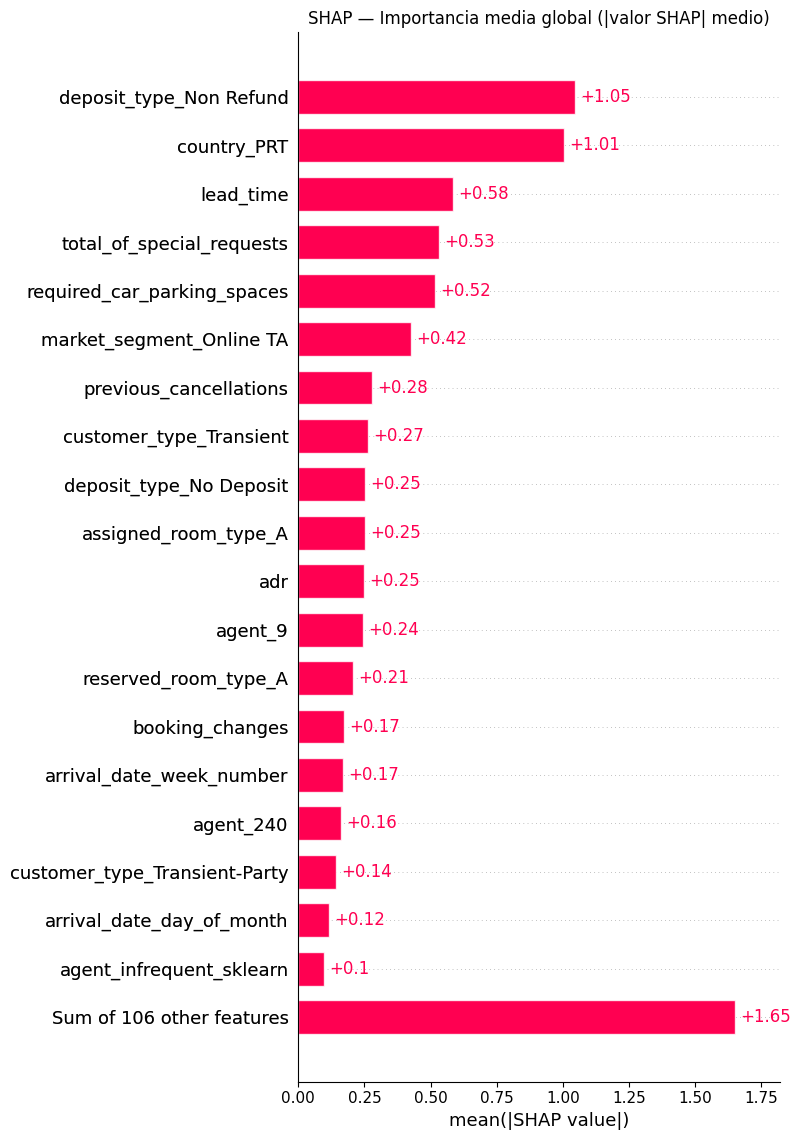

In [3]:
shap.plots.bar(explanation, max_display=20, show=False)
plt.title('SHAP — Importancia media global (|valor SHAP| medio)')
plt.tight_layout(); plt.show()

### 3.2. Beeswarm (enjambre): importancia **y** dirección

El *beeswarm* añade información que el gráfico de barras no muestra:

- **Cada punto** es una reserva.
- **Eje X**: su valor SHAP (derecha = empuja hacia *cancela*; izquierda = hacia *no cancela*).
- **Color**: el valor de la variable (rojo = alto, azul = bajo).

Así se lee de un vistazo la *dirección* del efecto: p. ej., si los puntos rojos de `lead_time` están a la derecha, significa que **más antelación → más cancelación**.

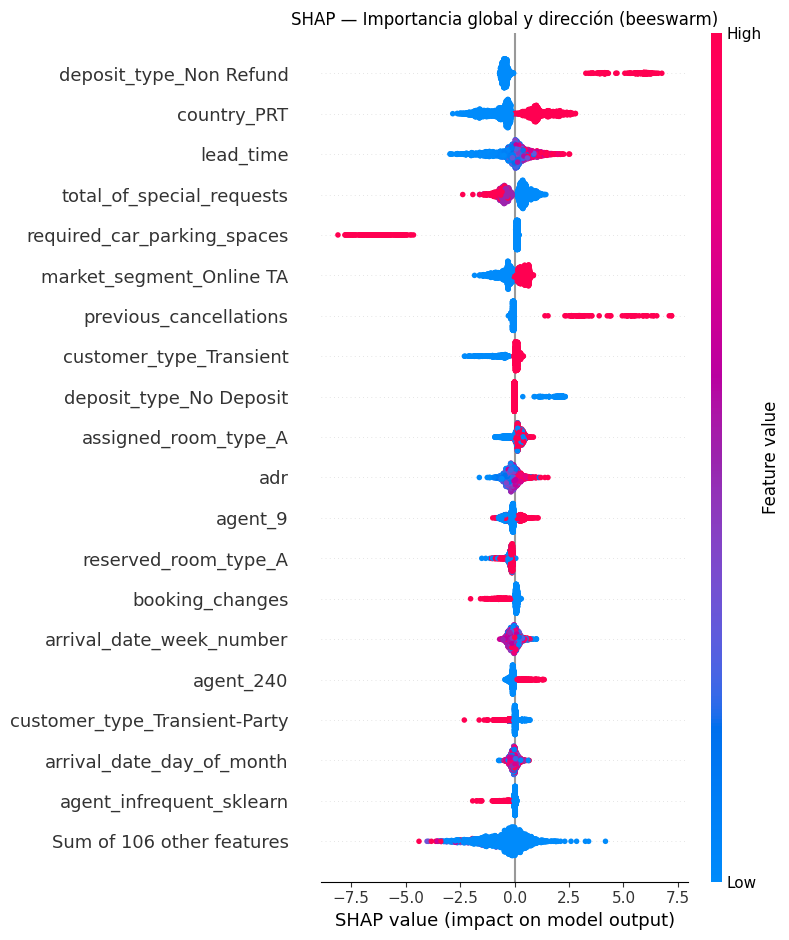

In [4]:
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title('SHAP — Importancia global y dirección (beeswarm)')
plt.tight_layout(); plt.show()

### 3.3. Lectura de los gráficos globales

Las variables con más peso (cabecera del ranking) son, de forma muy estable:

- **`deposit_type_Non Refund`**: cuando está activa (depósito no reembolsable), el valor SHAP es fuertemente positivo → empuja hacia *cancela*. Coincide con el EDA, donde este tipo de depósito tenía una tasa de cancelación **cercana al 99 %**.
- **`country_PRT`** (Portugal): el país del cliente discrimina mucho; las reservas desde Portugal (mercado dominante del dataset) tienden a cancelarse más.
- **`lead_time`** (días de antelación): valores altos (rojo) caen a la derecha → **a más antelación, más cancelación**, tal como anticipaba el EDA.
- **`total_of_special_requests`** y **`required_car_parking_spaces`**: actúan **al revés**; valores altos (clientes más comprometidos) empujan hacia *no cancela*.
- **`previous_cancellations`**: un historial de cancelaciones previas también sube el riesgo.

El modelo ha aprendido **exactamente los patrones del EDA**, lo que aumenta nuestra confianza en que generaliza por las razones correctas y no por artefactos.

## 4. Explicaciones locales: ¿por qué *esta* reserva?

El gráfico de **cascada** (*waterfall*) explica una predicción individual. Parte del **valor base** (`E[f(x)]`, la predicción media del modelo sobre todo el conjunto, expresada en *log-odds*) y va sumando/restando la contribución de cada variable hasta llegar a la predicción final `f(x)` de esa reserva. Las barras rojas empujan hacia *cancela* y las azules hacia *no cancela*.

Elegimos automáticamente dos casos extremos del test: la reserva con **mayor** probabilidad estimada de cancelación y la de **menor**.

In [5]:
ejemplos = interp.find_examples(pipeline, X_test)
proba = pipeline.predict_proba(X_test)[:, 1]
i1, i2 = ejemplos['alta_prob'], ejemplos['baja_prob']
print(f"Ejemplo 1 (alta prob): idx={i1}  p(cancela)={proba[i1]:.3f}  real={y_test.iloc[i1]}")
print(f"Ejemplo 2 (baja prob): idx={i2}  p(cancela)={proba[i2]:.3f}  real={y_test.iloc[i2]}")
cols = ['deposit_type', 'lead_time', 'country', 'previous_cancellations',
        'total_of_special_requests', 'market_segment']
X_test.iloc[[i1, i2]][cols].T.rename(columns={X_test.index[i1]: 'Ejemplo 1', X_test.index[i2]: 'Ejemplo 2'})

Ejemplo 1 (alta prob): idx=2698  p(cancela)=1.000  real=1
Ejemplo 2 (baja prob): idx=14313  p(cancela)=0.000  real=0


,Ejemplo 1,Ejemplo 2
deposit_type,Non Refund,No Deposit
lead_time,379,144
country,PRT,SWE
previous_cancellations,1,0
total_of_special_requests,0,2
market_segment,Groups,Offline TA/TO


### 4.1. Ejemplo 1 — reserva que el modelo da por **cancelada**

Una reserva con depósito *Non Refund*, mucha antelación (`lead_time` alto), desde Portugal y sin peticiones especiales: el perfil de riesgo máximo según el EDA.

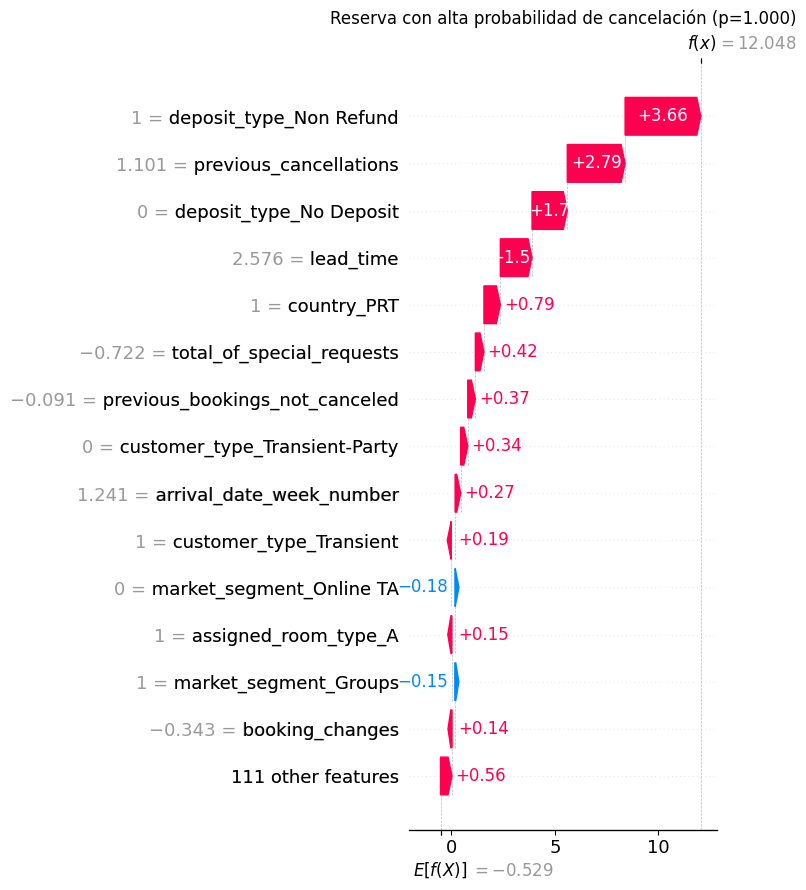

In [6]:
expl1, _, _ = interp._build_tree_explainer(pipeline, X_test.iloc[[i1]])
shap.plots.waterfall(expl1[0], max_display=15, show=False)
plt.title(f'Reserva con alta probabilidad de cancelación (p={proba[i1]:.3f})')
plt.tight_layout(); plt.show()

### 4.2. Ejemplo 2 — reserva que el modelo da por **no cancelada**

Aquí dominan las barras azules: depósito *No Deposit*, peticiones especiales, un país distinto de Portugal y sin cancelaciones previas tiran de la predicción hacia *no cancela*.

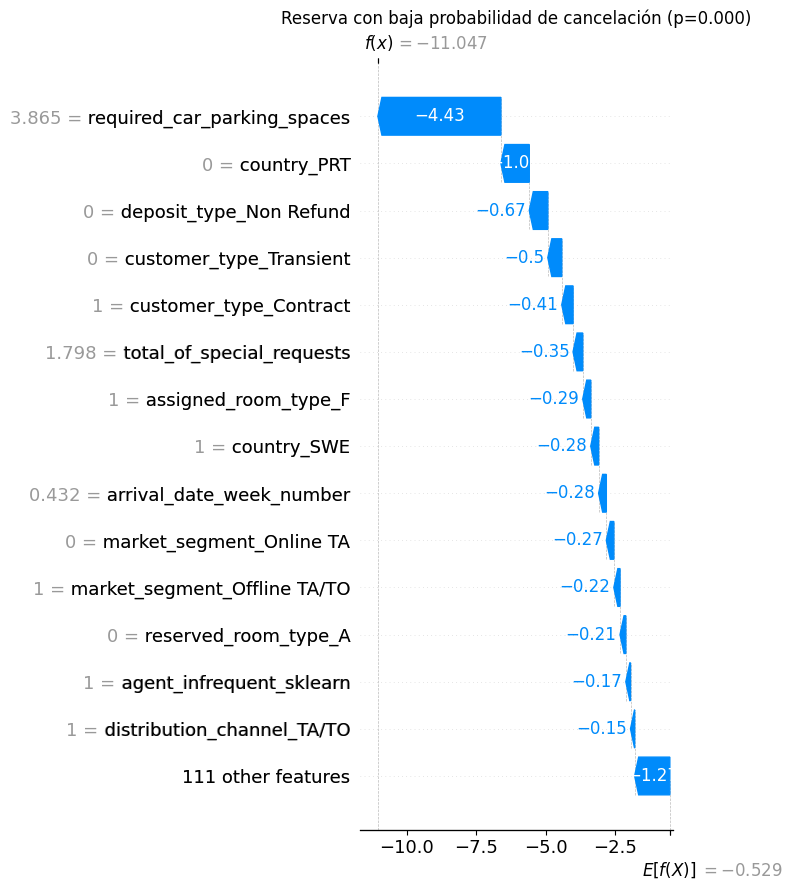

In [7]:
expl2, _, _ = interp._build_tree_explainer(pipeline, X_test.iloc[[i2]])
shap.plots.waterfall(expl2[0], max_display=15, show=False)
plt.title(f'Reserva con baja probabilidad de cancelación (p={proba[i2]:.3f})')
plt.tight_layout(); plt.show()

## 5. Contraste: importancia por permutación (agnóstica al modelo)

SHAP (aquí, `TreeExplainer`) es específico de árboles. Como **contraste independiente** usamos la **importancia por permutación**: barajamos al azar los valores de una variable y medimos cuánto cae el ROC-AUC. Si cae mucho, el modelo dependía de ella. Su gran ventaja es que es **agnóstica al modelo** (sirve para regresión logística, redes neuronales...) y atribuye la importancia a las variables **originales** (no a las columnas one-hot).

> Nota: se calcula con `n_repeats=10` sobre el test, por lo que tarda un poco.

In [8]:
tabla_perm, _ = interp.permutation_importance_report(pipeline, X_test, y_test, n_repeats=10, top_n=15)
tabla_perm.head(10)

,variable,importancia_media,importancia_std
0,country,0.095221,0.001546
1,deposit_type,0.077635,0.001772
2,lead_time,0.045517,0.000785
3,agent,0.041371,0.000916
4,market_segment,0.040924,0.001155
5,required_car_parking_spaces,0.036055,0.001239
6,customer_type,0.026115,0.001163
7,total_of_special_requests,0.025753,0.000755
8,previous_cancellations,0.022939,0.000478
9,assigned_room_type,0.021170,0.000585


La importancia por permutación **confirma** el ranking de SHAP: `deposit_type`, `country`, `lead_time` y `total_of_special_requests` encabezan ambas listas. Que dos técnicas distintas coincidan refuerza la fiabilidad de las conclusiones.

## 6. Conclusiones y conexión con el EDA

- El mejor modelo (XGBoost) **no es una caja negra opaca**: SHAP descompone cada predicción en contribuciones interpretables.
- Las variables que más manejan al modelo son las **mismas** que el EDA señaló como informativas: **`deposit_type='Non Refund'`** (tasa de cancelación ~99 %), **`country`** (Portugal como mercado dominante), **`lead_time`** (más antelación → más cancelación) y las peticiones especiales / plaza de aparcamiento (señales de compromiso que reducen el riesgo).
- A nivel **local**, el *waterfall* permite explicar reservas concretas al negocio ("esta reserva se marca como riesgo porque tiene depósito no reembolsable y 379 días de antelación").
- **Limitaciones**: SHAP se calcula sobre una submuestra (2000 reservas) por eficiencia; las variables de alta cardinalidad (`country`, `agent`) están agrupadas por el *one-hot* limitado, así que su importancia se reparte entre las categorías más frecuentes; y los valores SHAP del modelo de árboles se expresan en *log-odds*, no en probabilidad directa.

Todos los gráficos se regeneran de forma reproducible con:

```bash
cd project && python -m src.interpretability
```

Documentación didáctica detallada en [`../docs/interpretabilidad.md`](../docs/interpretabilidad.md).